In [1]:
import numpy as np
from ncon import ncon

In [2]:
def conversion_basis(number, new_basis, max_digits):
    assert number < new_basis**max_digits, (f"Number cannot be expressed in basis: {new_basis} with a maximum number of digits: {max_digits}")
    lsd = []
    quotient = 1
    while quotient != 0:
        quotient = number // new_basis
        number = number / new_basis
        reminder = number % 1
        lsd.append(int(reminder*new_basis))
    if len(lsd) < max_digits:
        len_digits = len(lsd)
        for _ in range(max_digits-len_digits):
            lsd.append(int(0))
    lsd.reverse()
    return lsd

def conversion_list_to_pauli_string(list):
    wrong_basis = False
    for num in list:
        if num > 3:
            wrong_basis = True
    assert wrong_basis == False, ("The list is not in the correct basis for Paulis")
    paulis = ['I','X','Y','Z']
    list_paulis = [paulis[i] for i in list]
    for i in range(1, len(list_paulis)):
        list_paulis[0] = list_paulis[0] + list_paulis[i]
    lp = list_paulis[0]
    return lp

def conversion_list_to_pauli_op(list):
    wrong_basis = False
    for num in list:
        if num > 3:
            wrong_basis = True
    assert wrong_basis == False, ("The list is not in the correct basis for Paulis")
    I = np.array([[1,0],[0,1]])
    X = np.array([[0,1],[1,0]])
    Y = np.array([[0,-1j],[1j,0]])
    Z = np.array([[1,0],[0,-1]])

    paulis = [I,X,Y,Z]
    list_paulis = [paulis[i] for i in list]
    return list_paulis

def generalized_pauli_op(list_paulis):
    n_qubits = len(list_paulis)
    contr = np.array([1]).reshape((1,1))
    for i in range(n_qubits):
        contr = ncon([contr, list_paulis[i]], [[-1,-3],[-2,-4]]).reshape((2**(i+1),2**(i+1)))
    return contr

def find_coeff_pauli(number, matrix):
    n_qubits = int(np.log2(len(matrix)))
    list_string = conversion_basis(number,4,n_qubits)
    list_paulis_string = conversion_list_to_pauli_string(list_string)
    list_paulis = conversion_list_to_pauli_op(list_string)
    pauli_op = generalized_pauli_op(list_paulis)
    coeff = 1/len(matrix)*np.trace(pauli_op @ matrix)
    return coeff, list_paulis_string

def pauli_decomposition(matrix, threshold: float=1e-15):
    n_qubits = int(np.log2(len(matrix)))
    coeffs = [find_coeff_pauli(num,matrix) for num in range(4**n_qubits)]
    coeffs_new = [[c[0],c[1]] for c in coeffs]
    lin_comb = []
    for coeff in coeffs_new:
        if coeff[0] > threshold:
            lin_comb.append(coeff)
    return lin_comb, coeffs_new

In [3]:
list = conversion_basis(4,4,2)
print(list)
conversion_list_to_pauli_string(list)

[1, 0]


'XI'

In [4]:
import numpy as np
I = np.array([[1,0],[0,1]])
X = np.array([[0,1],[1,0]])
Y = np.array([[0,1j],[1j,0]])
Z = np.array([[1,0],[0,-1]])
XX = np.kron(X,X)
print(XX)
XI = np.kron(X,I)
print(XI)
XX_XI = XX + XI
print(XX_XI)


[[0 0 0 1]
 [0 0 1 0]
 [0 1 0 0]
 [1 0 0 0]]
[[0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]
 [0 1 0 0]]
[[0 0 1 1]
 [0 0 1 1]
 [1 1 0 0]
 [1 1 0 0]]


In [5]:
list = conversion_basis(1,4,2)
print(list)
list_strings = conversion_list_to_pauli_string(list)
print(list_strings)
list_paulis = conversion_list_to_pauli_op(list)
pauli_op = generalized_pauli_op(list_paulis)
print(f"pauli op: \n{pauli_op}")
print(f"true one: \n{np.kron(X,I)}")

[0, 1]
IX
pauli op: 
[[0 1 0 0]
 [1 0 0 0]
 [0 0 0 1]
 [0 0 1 0]]
true one: 
[[0 0 1 0]
 [0 0 0 1]
 [1 0 0 0]
 [0 1 0 0]]


In [6]:
lc, coeffs = pauli_decomposition(XX_XI)
print(lc)
print(coeffs)
coeff_arr = np.array(coeffs)
print(coeff_arr.shape)

[[1.0, 'XI'], [1.0, 'XX']]
[[0.0, 'II'], [0.0, 'IX'], [0j, 'IY'], [0.0, 'IZ'], [1.0, 'XI'], [1.0, 'XX'], [0j, 'XY'], [0.0, 'XZ'], [0j, 'YI'], [0j, 'YX'], [0j, 'YY'], [0j, 'YZ'], [0.0, 'ZI'], [0.0, 'ZX'], [0j, 'ZY'], [0.0, 'ZZ']]
(16, 2)


C:\Users\HP\AppData\Local\Temp\ipykernel_7852\181125327.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap("Greys")


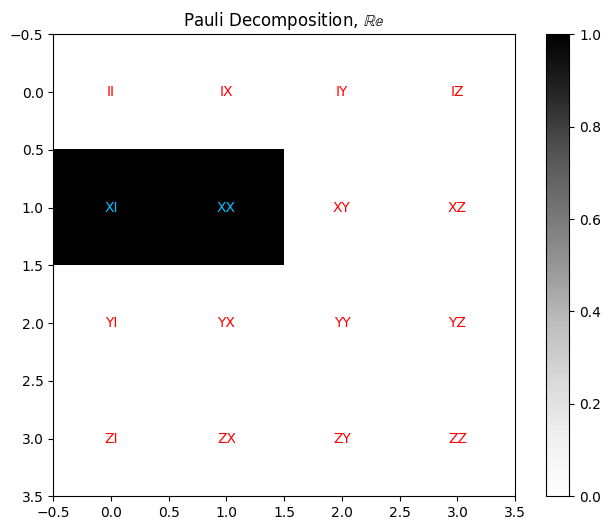

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

n_qubits = 2
data = np.asarray([c[0] for c in coeffs]).reshape((2**n_qubits,2**n_qubits))
labels = np.asarray([c[1] for c in coeffs]).reshape((2**n_qubits,2**n_qubits))
lc_labels = [l[1] for l in lc]
plt.figure(figsize=(8, 6))
plt.imshow(np.real(data), cmap='Greys', interpolation='nearest')

# Add title and labels
plt.title('Pauli Decomposition, $\mathbb{Re}$')

# Show color bar to indicate the values
plt.colorbar()

# Add text annotations
colormap = plt.cm.get_cmap("Greys")
colormap_values = np.linspace(0, 1, 4**n_qubits)
colors = [colormap(value) for value in colormap_values]
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if labels[i,j] in lc_labels:
            color = "deepskyblue"
        else:
            color = "red"
        plt.text(j, i, f'{labels[i, j]}', ha='center', va='center', color=color)

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_7852\1898678501.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap("Greys")


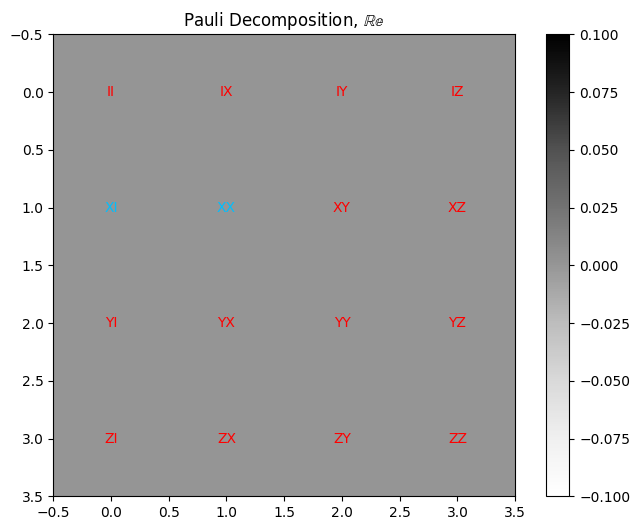

In [10]:
plt.figure(figsize=(8, 6))
plt.imshow(np.imag(data), cmap='Greys', interpolation='nearest')

# Add title and labels
plt.title('Pauli Decomposition, $\mathbb{Im}$')

# Show color bar to indicate the values
plt.colorbar()

# Add text annotations
colormap = plt.cm.get_cmap("Greys")
colormap_values = np.linspace(0, 1, 4**n_qubits)
colors = [colormap(value) for value in colormap_values]
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        if labels[i,j] in lc_labels:
            color = "deepskyblue"
        else:
            color = "red"
        plt.text(j, i, f'{labels[i, j]}', ha='center', va='center', color=color)

plt.show()